In [1]:
!pip install torchvision networkx matplotlib pillow -q

In [2]:
import re
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
model.eval().to(device)

# COCO class names (index 0 is background)
COCO_CLASSES = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT.meta['categories']
print('Model loaded. Classes available:', len(COCO_CLASSES))

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 178MB/s]


Model loaded. Classes available: 91


Saving WhatsApp Image 2026-08-20 at 1.03.25 AM.jpeg to WhatsApp Image 2026-08-20 at 1.03.25 AM.jpeg


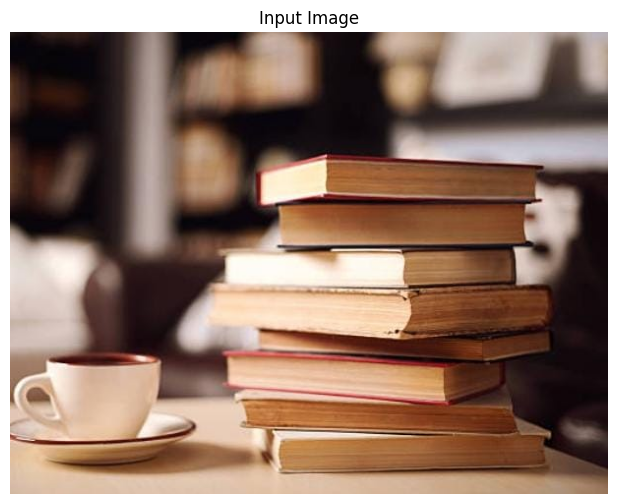

In [3]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
img = Image.open(image_path).convert('RGB')
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis('off')
plt.title('Input Image')
plt.show()

Detected 12 objects above confidence 0.6:
  cup: 1.00
  book_1: 0.96
  book_2: 0.89
  book_3: 0.87
  book_4: 0.77
  book_5: 0.75
  book_6: 0.72
  person: 0.71
  book_7: 0.71
  bowl: 0.68
  chair: 0.65
  dining table: 0.62


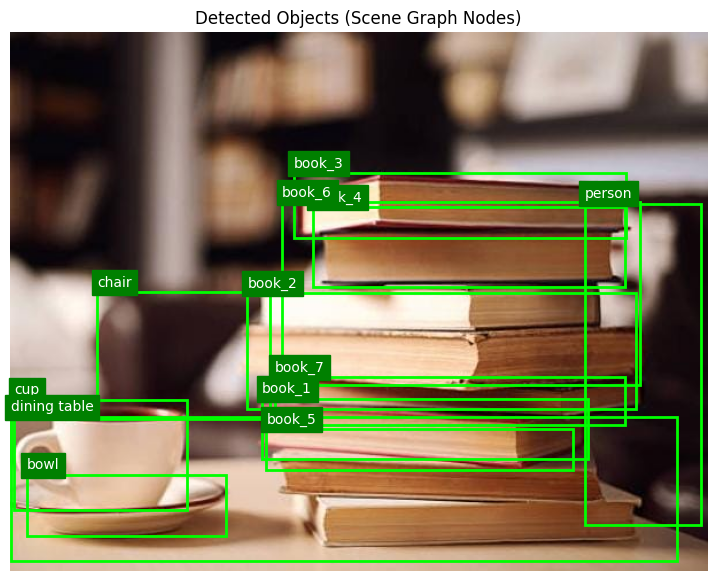

In [4]:
img_tensor = F.to_tensor(img).to(device)
with torch.no_grad():
    prediction = model([img_tensor])[0]

CONF_THRESH = 0.6
boxes, labels, scores = [], [], []
for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
    if score >= CONF_THRESH:
        boxes.append(box.cpu().numpy())
        labels.append(COCO_CLASSES[label.item()])
        scores.append(score.item())

# Make node names unique (e.g. two chairs -> chair_1, chair_2) so reasoning/queries
# can refer to a specific instance instead of merging every 'chair' into one node.
counts = {}
node_names = []
for l in labels:
    counts[l] = counts.get(l, 0) + 1
    node_names.append(f'{l}_{counts[l]}' if labels.count(l) > 1 else l)

print(f'Detected {len(boxes)} objects above confidence {CONF_THRESH}:')
for n, s in zip(node_names, scores):
    print(f'  {n}: {s:.2f}')

fig, ax = plt.subplots(1, figsize=(9,7))
ax.imshow(img)
for box, name in zip(boxes, node_names):
    x1,y1,x2,y2 = box
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-5, name, color='white', fontsize=10, backgroundcolor='green')
plt.axis('off')
plt.title('Detected Objects (Scene Graph Nodes)')
plt.savefig('detections.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
def iou(b1, b2):
    x1 = max(b1[0], b2[0]); y1 = max(b1[1], b2[1])
    x2 = min(b1[2], b2[2]); y2 = min(b1[3], b2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
    a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)

def infer_relationship(b1, b2):
    c1 = ((b1[0]+b1[2])/2, (b1[1]+b1[3])/2)
    c2 = ((b2[0]+b2[2])/2, (b2[1]+b2[3])/2)
    overlap = iou(b1, b2)

    if overlap > 0.3:
        if b1[3] <= b2[3]:
            return 'on'
        else:
            return 'under'
    dx, dy = c2[0]-c1[0], c2[1]-c1[1]
    dist = (dx**2 + dy**2) ** 0.5
    diag = ((img.width)**2 + (img.height)**2) ** 0.5
    if dist / diag > 0.5:
        return None  # too far, skip
    if abs(dy) > abs(dx):
        return 'in front of' if dy > 0 else 'behind'
    else:
        return 'right of' if dx > 0 else 'left of'

triplets = []
for i in range(len(boxes)):
    for j in range(len(boxes)):
        if i == j: continue
        rel = infer_relationship(boxes[i], boxes[j])
        if rel:
            triplets.append((node_names[i], rel, node_names[j]))

triplets = list(dict.fromkeys(triplets))
print('Scene graph triplets (subject - predicate - object):')
for t in triplets:
    print(f'  {t[0]} --{t[1]}--> {t[2]}')

Scene graph triplets (subject - predicate - object):
  cup --right of--> book_1
  cup --right of--> book_2
  cup --right of--> book_3
  cup --right of--> book_4
  cup --right of--> book_5
  cup --right of--> book_6
  cup --right of--> book_7
  cup --in front of--> bowl
  cup --behind--> chair
  cup --right of--> dining table
  book_1 --left of--> cup
  book_1 --behind--> book_2
  book_1 --behind--> book_3
  book_1 --behind--> book_4
  book_1 --on--> book_5
  book_1 --behind--> book_6
  book_1 --right of--> person
  book_1 --behind--> book_7
  book_1 --left of--> bowl
  book_1 --left of--> chair
  book_1 --left of--> dining table
  book_2 --left of--> cup
  book_2 --in front of--> book_1
  book_2 --behind--> book_3
  book_2 --behind--> book_4
  book_2 --in front of--> book_5
  book_2 --under--> book_6
  book_2 --right of--> person
  book_2 --in front of--> book_7
  book_2 --left of--> bowl
  book_2 --left of--> chair
  book_2 --in front of--> dining table
  book_3 --left of--> cup
  boo

In [6]:
INVERSES = {
    'on': 'under', 'under': 'on',
    'left of': 'right of', 'right of': 'left of',
    'in front of': 'behind', 'behind': 'in front of',
}

def add_inverse_edges(triplets):
    triplet_set = set(triplets)
    augmented = list(triplets)
    for s, p, o in triplets:
        inv = INVERSES.get(p)
        if inv and (o, inv, s) not in triplet_set:
            augmented.append((o, inv, s))
            triplet_set.add((o, inv, s))
    return augmented

def add_near_relations(triplets):
    near_pairs = set()
    for s, p, o in triplets:
        pair = tuple(sorted((s, o)))
        near_pairs.add(pair)
    near_triplets = [(a, 'near', b) for a, b in near_pairs] + [(b, 'near', a) for a, b in near_pairs]
    return near_triplets

reasoned_triplets = add_inverse_edges(triplets)
near_triplets = add_near_relations(triplets)
all_triplets = list(dict.fromkeys(reasoned_triplets + near_triplets))

print(f'Original triplets: {len(triplets)}')
print(f'After adding inverse relations: {len(reasoned_triplets)}')
print(f'After adding derived near relations: {len(all_triplets)}')
print()
print('New facts added by the reasoning module:')
for t in all_triplets:
    if t not in triplets:
        print(f'  {t[0]} --{t[1]}--> {t[2]}')

Original triplets: 124
After adding inverse relations: 124
After adding derived near relations: 248

New facts added by the reasoning module:
  bowl --near--> dining table
  book_2 --near--> book_5
  book_3 --near--> dining table
  book_6 --near--> bowl
  book_5 --near--> dining table
  book_2 --near--> person
  book_2 --near--> chair
  book_3 --near--> book_5
  book_4 --near--> dining table
  book_1 --near--> book_2
  book_2 --near--> book_3
  book_3 --near--> person
  book_6 --near--> cup
  book_3 --near--> chair
  bowl --near--> chair
  book_2 --near--> bowl
  book_4 --near--> book_5
  book_5 --near--> person
  book_5 --near--> chair
  book_6 --near--> book_7
  book_1 --near--> dining table
  book_4 --near--> person
  book_4 --near--> chair
  book_5 --near--> bowl
  book_2 --near--> book_4
  book_2 --near--> cup
  book_2 --near--> book_6
  book_4 --near--> bowl
  book_1 --near--> book_5
  chair --near--> dining table
  book_7 --near--> dining table
  book_2 --near--> book_7
  book_3

In [8]:
def resolve_object(name, node_names):
    name = name.strip().lower()
    exact = [n for n in node_names if n.lower() == name]
    if exact:
        return exact
    partial = [n for n in node_names if n.lower().split('_')[0] == name]
    return partial

def answer_query(query, all_triplets, node_names):
    q = query.strip().lower().rstrip('?')

    m = re.match(r'what is (on|under|near) (.+)', q)
    if m:
        rel, obj_raw = m.groups()
        matches = resolve_object(obj_raw, node_names)
        if not matches:
            return f"I don't see '{obj_raw}' in the scene."
        results = []
        for obj in matches:
            found = [s for s, p, o in all_triplets if p == rel and o == obj]
            if found:
                results.append(f"{', '.join(found)} {'is' if len(found)==1 else 'are'} {rel} {obj}")
        return '; '.join(results) if results else f'Nothing found {rel} {obj_raw}.'

    m = re.match(r'is (.+) near (.+)', q)
    if m:
        a_raw, b_raw = m.groups()
        a_matches, b_matches = resolve_object(a_raw, node_names), resolve_object(b_raw, node_names)
        if not a_matches or not b_matches:
            return f"I don't recognize one of '{a_raw}' / '{b_raw}'."
        for a in a_matches:
            for b in b_matches:
                if (a, 'near', b) in all_triplets:
                    return f'Yes, {a} is near {b}.'
        return f'No, {a_raw} does not appear near {b_raw}.'

    m = re.match(r'is (.+) (on|under|left of|right of|in front of|behind) (.+)', q)
    if m:
        a_raw, rel, b_raw = m.groups()
        a_matches, b_matches = resolve_object(a_raw, node_names), resolve_object(b_raw, node_names)
        if not a_matches or not b_matches:
            return f"I don't recognize one of '{a_raw}' / '{b_raw}'."
        for a in a_matches:
            for b in b_matches:
                if (a, rel, b) in all_triplets:
                    return f'Yes, {a} is {rel} {b}.'
        return f'No, {a_raw} is not {rel} {b_raw}.'

    m = re.match(r'list relations (.+)', q)
    if m:
        obj_raw = m.group(1)
        matches = resolve_object(obj_raw, node_names)
        if not matches:
            return f"I don't see '{obj_raw}' in the scene."
        lines = []
        for obj in matches:
            for s, p, o in all_triplets:
                if s == obj:
                    lines.append(f'{s} --{p}--> {o}')
        return '\n'.join(lines) if lines else f'No relations found for {obj_raw}.'

    return "Sorry, I can only answer questions like 'what is on X?', 'is X near Y?', 'is X left of Y?' or 'list relations X'."


demo_queries = [
    'list relations ' + node_names[0] if node_names else 'list relations table',
]
for q in demo_queries:
    print(f'Q: {q}')
    print(f'A: {answer_query(q, all_triplets, node_names)}')
    print()

Q: list relations cup
A: cup --right of--> book_1
cup --right of--> book_2
cup --right of--> book_3
cup --right of--> book_4
cup --right of--> book_5
cup --right of--> book_6
cup --right of--> book_7
cup --in front of--> bowl
cup --behind--> chair
cup --right of--> dining table
cup --near--> dining table
cup --near--> book_6
cup --near--> book_2
cup --near--> book_3
cup --near--> bowl
cup --near--> book_5
cup --near--> book_4
cup --near--> book_1
cup --near--> chair
cup --near--> book_7



In [9]:
# Interactive query loop - run this cell and type questions about the scene.
# Type 'exit' to stop.
while True:
    try:
        q = input('Ask about the scene (or "exit"): ')
    except EOFError:
        break
    if q.strip().lower() in ('exit', 'quit', ''):
        break
    print('A:', answer_query(q, all_triplets, node_names))

Ask about the scene (or "exit"): what on thr chair
A: Sorry, I can only answer questions like 'what is on X?', 'is X near Y?', 'is X left of Y?' or 'list relations X'.
Ask about the scene (or "exit"): exit


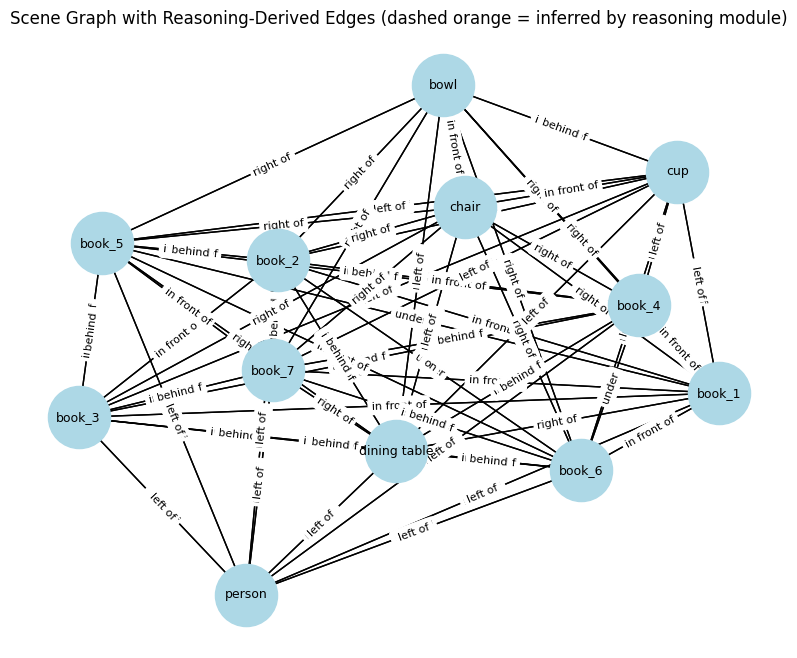

In [10]:
G = nx.DiGraph()
for s, p, o in triplets:
    G.add_edge(s, o, label=p, kind='detected')
for s, p, o in all_triplets:
    if (s, p, o) not in triplets and p != 'near':
        G.add_edge(s, o, label=p, kind='inferred')

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42, k=1.2)
detected_edges = [(u,v) for u,v,d in G.edges(data=True) if d['kind']=='detected']
inferred_edges = [(u,v) for u,v,d in G.edges(data=True) if d['kind']=='inferred']

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, edgelist=detected_edges, edge_color='black', arrows=True, arrowsize=20)
nx.draw_networkx_edges(G, pos, edgelist=inferred_edges, edge_color='orange', style='dashed', arrows=True, arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title('Scene Graph with Reasoning-Derived Edges (dashed orange = inferred by reasoning module)')
plt.axis('off')
plt.savefig('scene_graph_reasoned.png', dpi=150, bbox_inches='tight')
plt.show()